In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rounakbanik/the-movies-dataset/ratings.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/links_small.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/credits.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/keywords.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/movies_metadata.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/ratings_small.csv
/kaggle/input/datasets/rounakbanik/the-movies-dataset/links.csv


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import ast #for parsing stored lists in the data

#makes plots look clean
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [11]:
movies = pd.read_csv('/kaggle/input/datasets/rounakbanik/the-movies-dataset/movies_metadata.csv', low_memory=False)

print("Shape:", movies.shape)
movies.head(3)

Shape: (45466, 24)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0


In [12]:
# Drop rows with missing critical fields
movies = movies.dropna(subset=['title', 'release_date', 'vote_average', 'vote_count'])

# Convert types
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
movies['year'] = movies['release_date'].dt.year
movies['vote_average'] = pd.to_numeric(movies['vote_average'], errors='coerce')
movies['vote_count'] = pd.to_numeric(movies['vote_count'], errors='coerce')
movies['revenue'] = pd.to_numeric(movies['revenue'], errors='coerce')
movies['budget'] = pd.to_numeric(movies['budget'], errors='coerce')

# Filter out movies with very few votes (unreliable ratings)
movies_filtered = movies[movies['vote_count'] >= 50].copy()

print(f"Movies after cleaning: {len(movies_filtered):,}")

Movies after cleaning: 9,150


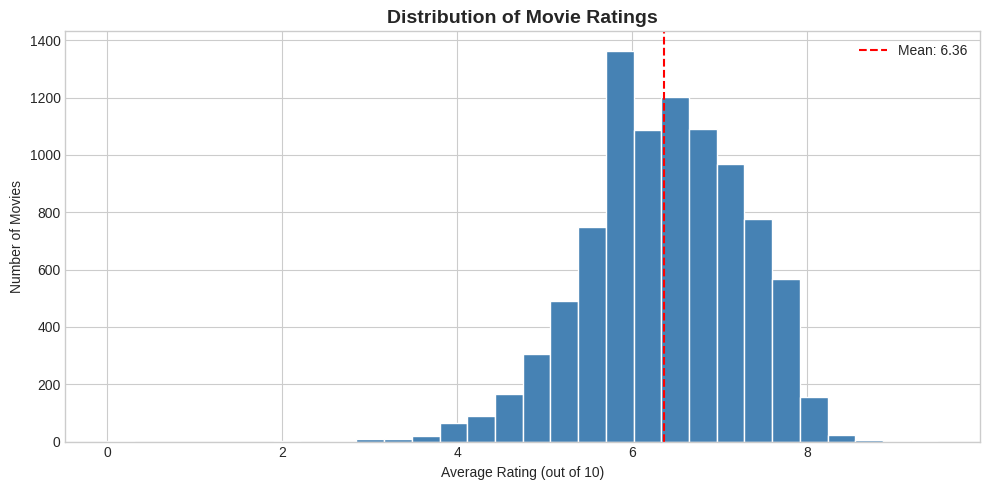

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(movies_filtered['vote_average'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Movie Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating (out of 10)')
plt.ylabel('Number of Movies')
plt.axvline(movies_filtered['vote_average'].mean(), color='red', linestyle='--', 
            label=f"Mean: {movies_filtered['vote_average'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150)
plt.show()

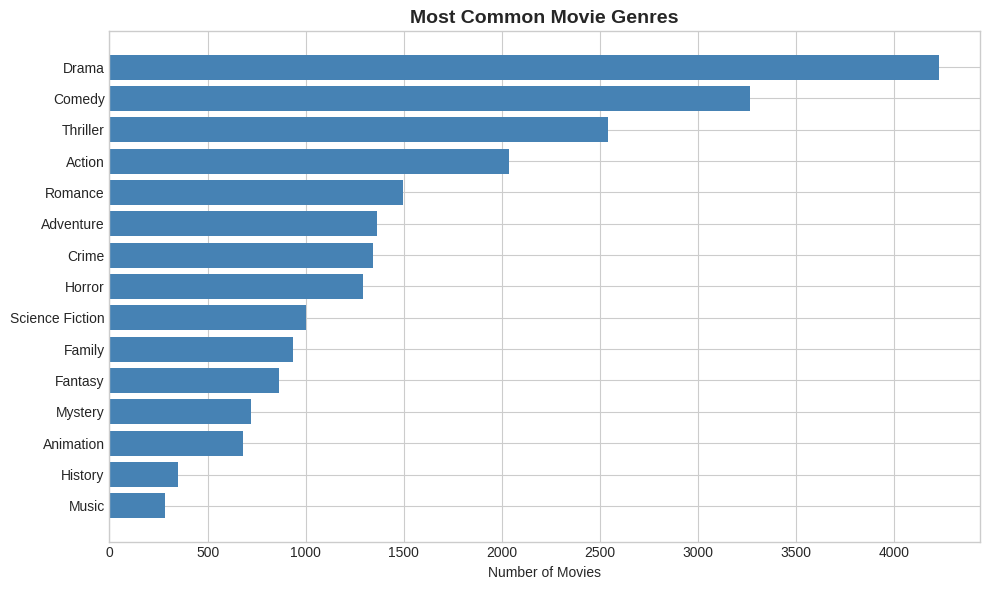

In [14]:
# genres column is stored as a string like "[{'id': 28, 'name': 'Action'}]"
# ast.literal_eval converts it back to a real Python list
def extract_genres(genre_str):
    try:
        genres = ast.literal_eval(genre_str)
        return [g['name'] for g in genres]
    except:
        return []

movies_filtered['genre_list'] = movies_filtered['genres'].apply(extract_genres)

# Flatten all genres into one list and count
from collections import Counter
all_genres = [g for sublist in movies_filtered['genre_list'] for g in sublist]
genre_counts = Counter(all_genres)

genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count'])
genre_df = genre_df.sort_values('Count', ascending=True).tail(15)

plt.figure(figsize=(10, 6))
plt.barh(genre_df['Genre'], genre_df['Count'], color='steelblue')
plt.title('Most Common Movie Genres', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies')
plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150)
plt.show()

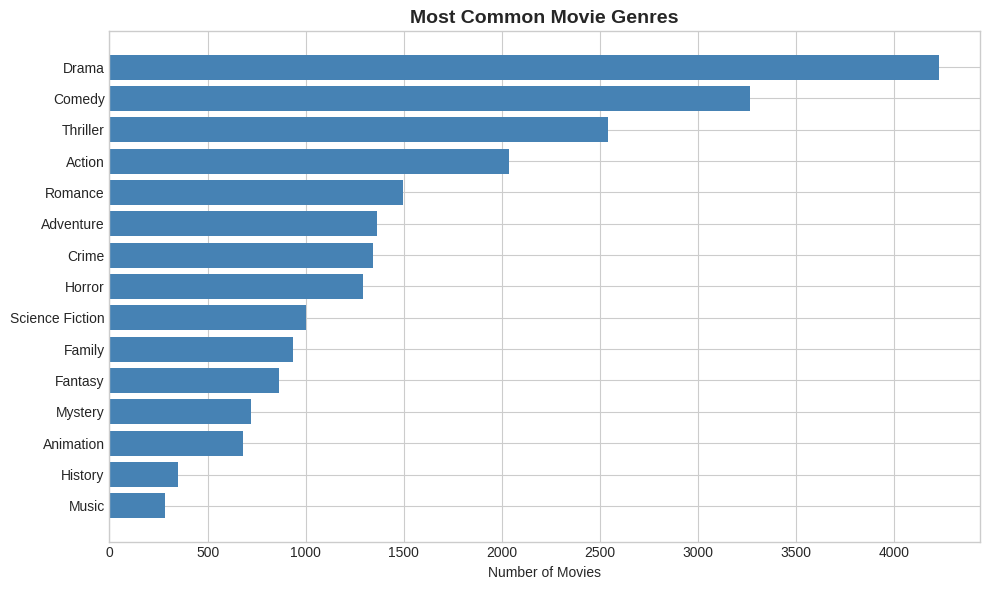

In [15]:
# genres column is stored as a string like "[{'id': 28, 'name': 'Action'}]"
# ast.literal_eval converts it back to a real Python list
def extract_genres(genre_str):
    try:
        genres = ast.literal_eval(genre_str)
        return [g['name'] for g in genres]
    except:
        return []

movies_filtered['genre_list'] = movies_filtered['genres'].apply(extract_genres)

# Flatten all genres into one list and count
from collections import Counter
all_genres = [g for sublist in movies_filtered['genre_list'] for g in sublist]
genre_counts = Counter(all_genres)

genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count'])
genre_df = genre_df.sort_values('Count', ascending=True).tail(15)

plt.figure(figsize=(10, 6))
plt.barh(genre_df['Genre'], genre_df['Count'], color='steelblue')
plt.title('Most Common Movie Genres', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies')
plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150)
plt.show()

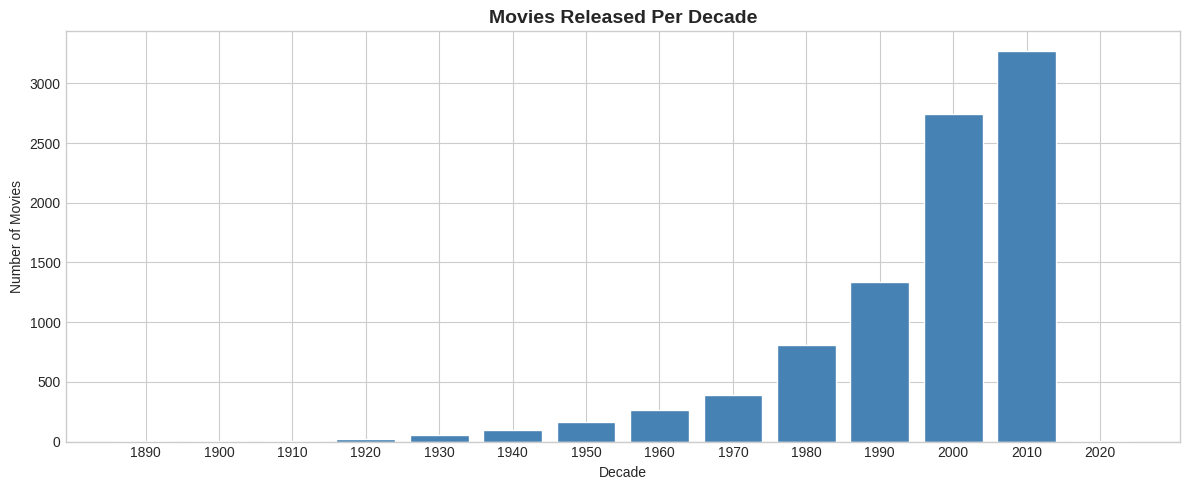

In [16]:
movies_filtered['decade'] = (movies_filtered['year'] // 10 * 10).astype('Int64')
decade_counts = movies_filtered['decade'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(decade_counts.index.astype(str), decade_counts.values, color='steelblue', edgecolor='white')
plt.title('Movies Released Per Decade', fontsize=14, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('movies_per_decade.png', dpi=150)
plt.show()

In [17]:

top_movies = movies_filtered[movies_filtered['vote_count'] >= 500]\
    .sort_values('vote_average', ascending=False)\
    [['title', 'vote_average', 'vote_count', 'year']]\
    .head(10)\
    .reset_index(drop=True)

top_movies.index += 1  # start rank from 1
print("Top 10 Highest Rated Movies:\n")
print(top_movies.to_string())

Top 10 Highest Rated Movies:

                          title  vote_average  vote_count  year
1   Dilwale Dulhania Le Jayenge           9.1       661.0  1995
2                    Your Name.           8.5      1030.0  2016
3                 The Godfather           8.5      6024.0  1972
4      The Shawshank Redemption           8.5      8358.0  1994
5             Life Is Beautiful           8.3      3643.0  1997
6              Schindler's List           8.3      4436.0  1993
7               The Dark Knight           8.3     12269.0  2008
8   Once Upon a Time in America           8.3      1104.0  1984
9                    Fight Club           8.3      9678.0  1999
10       The Godfather: Part II           8.3      3418.0  1974


In [18]:
average_rating = top_movies['vote_average'].mean()
print("Average rating:", average_rating)

Average rating: 8.440000000000001


## Key Findings

- The average movie rating is 844, with most movies clustering between 8 and 8.5
- Drama and Comedy are the most produced genres by far
- Movie production increased sharply from the 1990s onward
- High vote counts don't always mean high ratings — popular ≠ best